In [ ]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

# Helpers

In [ ]:
import os
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import spearmanr

from src.pref_models import fit_feature_based_bradley_terry, fit_item_bradley_terry
from src.auxiliary import load_scores_by_run, find_any_scores_csv, get_item_feature_map
from src.metrics import compute_adherence_rank_correlations, decompose_item_shift
from src.plots import (
    plot_preference_shift,
    plot_laptop_ranking_shift,
    plot_feature_weight_trajectories,
    plot_shift_attribution,
    plot_laptop_feature_weights,
)

In [9]:
# def create_item_id(df):
#     cols_a = [col for col in df.columns if "a_" in col]
#     cols_b = [col.replace('a_','b_') for col in cols_a]
#     df['item_a'] = df.apply(lambda row: '-'.join([row[colname] for colname in cols_a]), axis=1)
#     df['item_b'] = df.apply(lambda row: '-'.join([row[colname] for colname in cols_b]), axis=1)
#     return df


# def create_item_mapping(df_raw_scores: pd.DataFrame,
#                         item_i_col='option_a',
#                         item_j_col='option_b') -> dict:
#     """Maps unique string items to integer indices 0 to N-1."""
#     items = pd.concat([df_raw_scores[item_i_col], df_raw_scores[item_j_col]]).unique()
#     return {item: idx for idx, item in enumerate(sorted(items))}

# def fit_bradley_terry_statsmodels(df: pd.DataFrame, item_mapping: dict, 
#                               item_i_col='option_a', item_j_col='option_b',
#                               score_a_col='score_a', score_b_col='score_b') -> dict:
#     """
#     Fits the Bradley-Terry model with Positional Bias and returns a structured dictionary.
#     """
#     n_samples = len(df)
#     n_items = len(item_mapping)
    
#     # 1. Target Variable Y (Log-Odds)
#     Y = (df[score_a_col] - df[score_b_col]).values
    
#     # 2. Design Matrix X
#     X_base = np.zeros((n_samples, n_items))
#     i_indices = df[item_i_col].map(item_mapping).values
#     j_indices = df[item_j_col].map(item_mapping).values
    
#     row_indices = np.arange(n_samples)
#     X_base[row_indices, i_indices] = 1
#     X_base[row_indices, j_indices] = -1
    
#     # Drop the last item column to avoid perfect multicollinearity
#     X_base = X_base[:, :-1] 
    
#     # Add the Intercept for gamma (Positional Bias)
#     X = sm.add_constant(X_base) 
    
#     # 3. Fit the OLS Model
#     model = sm.OLS(Y, X)
#     results = model.fit()
    
#     # 4. Extract Bias and P-Value
#     # 'const' is always at index 0 in statsmodels when using add_constant
#     gamma_bias = results.params[0]
#     gamma_pvalue = results.pvalues[0]
    
#     # 5. Extract and format Item Scores
#     # The coefficients for the items start at index 1. 
#     # We append a 0.0 for the reference item we dropped earlier.
#     raw_item_scores = np.append(results.params[1:], 0.0)
    
#     # Mean-center the scores so they are centered around 0 (standard for BT models)
#     centered_scores = raw_item_scores - np.mean(raw_item_scores)
    
#     # Reverse the mapping to get {index: 'ItemName'}
#     idx_to_item = {idx: item for item, idx in item_mapping.items()}
    
#     # Create a dictionary of {ItemName: Score}
#     item_scores_dict = {idx_to_item[i]: score for i, score in enumerate(centered_scores)}
    
#     # 6. Compile the final dictionary
#     output_dict = {
#         "item_scores": item_scores_dict,
#         "positional_bias_gamma": gamma_bias,
#         "gamma_pvalue": gamma_pvalue,
#         "model_r_squared": results.rsquared, # Good to keep for diagnostics!
#         "f_stat_pvalue": results.f_pvalue    # Tests if the whole model is significant
#     }
    
#     return output_dict


# Robustness New

In [ ]:
def run_laptop_ranking_experiment(basedir, filters, constraint_order,
                                  fit_fn=fit_item_bradley_terry, **plot_kwargs):
    """
    Glue: load+fit every run matching `filters` under `basedir`, draw the ranking
    bump chart, and print the adherence rank correlations for each consecutive
    shift in `constraint_order`. Lives in the notebook because this is the part
    we keep changing per experiment - the pieces it calls live in src/.

    Returns (scores_by_run, run_order, correlation_results).
    """
    scores_by_run, run_order, constraints_by_run = load_scores_by_run(
        basedir, filters, constraint_order, fit_fn=fit_fn
    )
    plot_laptop_ranking_shift(scores_by_run, run_order, constraints_by_run, **plot_kwargs)
    correlation_results = compute_adherence_rank_correlations(scores_by_run, run_order)
    return scores_by_run, run_order, correlation_results

## Qwen

Loaded 68339919 -> 32-14
Feature p-values:
  brand_Apple: p-value = 0.0567
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.0147
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -6.9349, p-value = 0.0000
Model R-squared: 0.8050, F-statistic p-value: 0.0000
Loaded 68373841 -> 32-
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.0000
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -6.9840, p-value = 0.0000
Model R-squared: 0.8533, F-statistic p-value: 0.0000
Loaded 68374115 -> 32-14_8
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.0006
  screen_14-inch: p-value = 0.0000
 

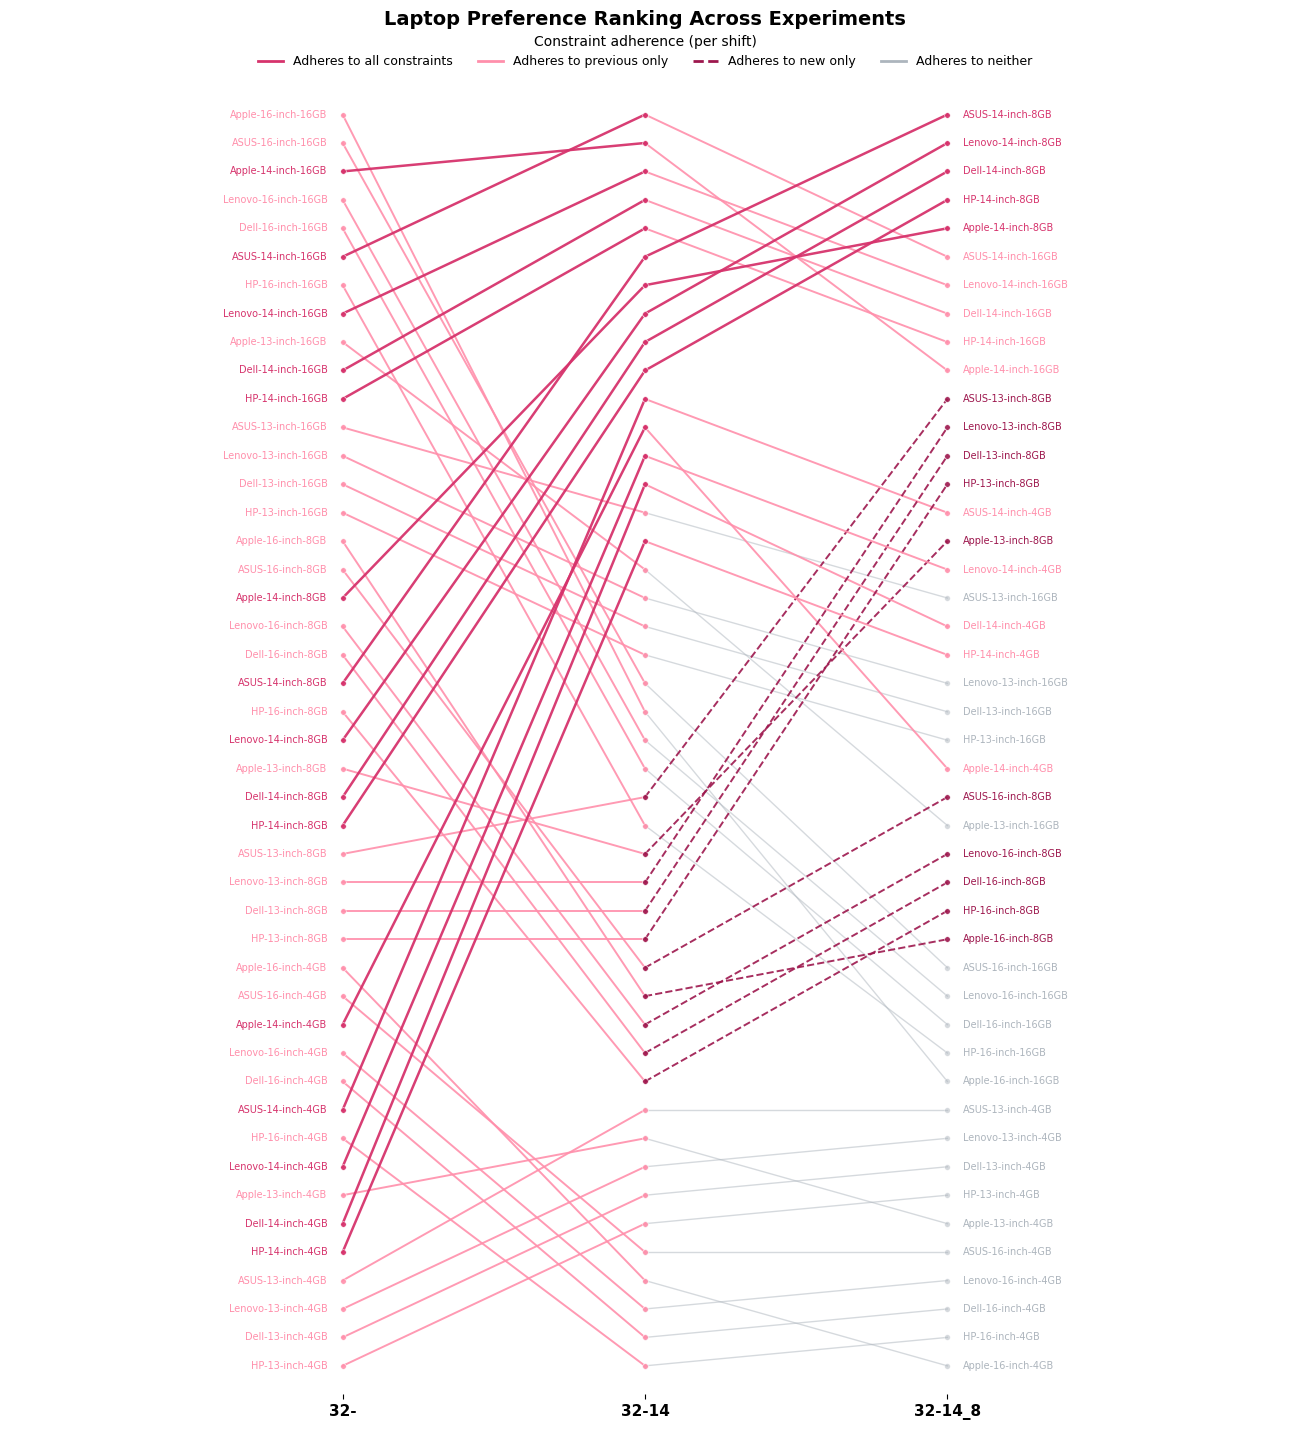

Shift 32- -> 32-14:
  Adhering  (14-inch, n=15): rho = 0.989
  Violating (not 14-inch, n=30): rho = 0.825
Shift 32-14 -> 32-14_8:
  Adhering  (14-inch, n=15): rho = 0.489
  Violating (not 14-inch, n=30): rho = 0.708


In [13]:
scores_by_run, run_order, correlation_results = run_laptop_ranking_experiment(
    basedir="data/laptops_robustness",
    filters={"model_size": "32"},
    constraint_order=["none", "screen=14-inch", "ram=8GB+screen=14-inch"],
)

Loaded 68337596 -> 7-14
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0006
  brand_HP: p-value = 0.0046
  brand_Lenovo: p-value = 0.0310
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.6567
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -8.9796, p-value = 0.0000
Model R-squared: 0.8170, F-statistic p-value: 0.0000
Loaded 68373840 -> 7-
Feature p-values:
  brand_Apple: p-value = 0.3800
  brand_Dell: p-value = 0.0006
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.0000
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -9.0486, p-value = 0.0000
Model R-squared: 0.8642, F-statistic p-value: 0.0000
Loaded 68374113 -> 7-14_8
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0103
  brand_HP: p-value = 0.0021
  brand_Lenovo: p-value = 0.1009
  screen_14-inch: p-value = 0.0000
  sc

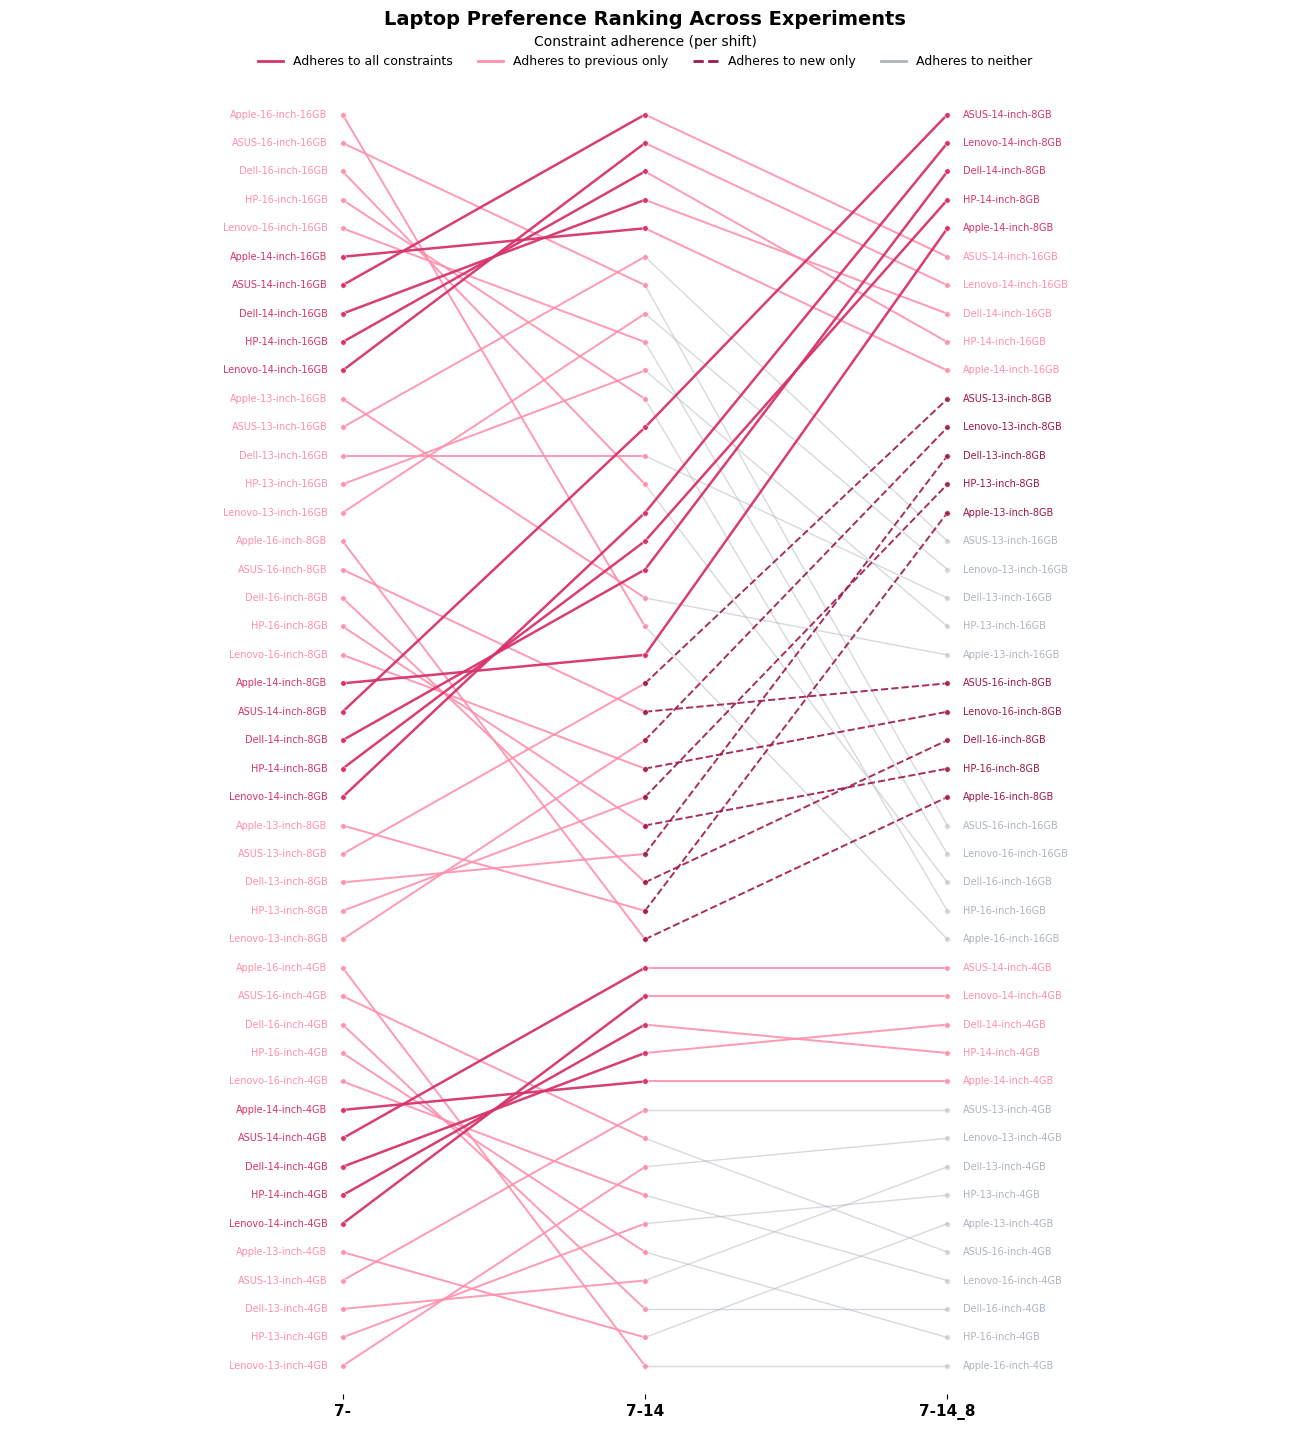

Shift 7- -> 7-14:
  Adhering  (14-inch, n=15): rho = 0.850
  Violating (not 14-inch, n=30): rho = 0.852
Shift 7-14 -> 7-14_8:
  Adhering  (14-inch, n=15): rho = 0.543
  Violating (not 14-inch, n=30): rho = 0.632


In [14]:
scores_by_run, run_order, correlation_results = run_laptop_ranking_experiment(
    basedir="data/laptops_robustness",
    filters={"model_size": "7"},
    constraint_order=["none", "screen=14-inch", "ram=8GB+screen=14-inch"],
)

Loaded 68339918 -> 0.5-14
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0212
  brand_HP: p-value = 0.0542
  brand_Lenovo: p-value = 0.0002
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0668
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0065
Positional bias (gamma): -0.2615, p-value = 0.0000
Model R-squared: 0.3074, F-statistic p-value: 0.0000
Loaded 68374669 -> 0.5-14_8
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0001
  brand_Lenovo: p-value = 0.0000
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0004
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -0.3746, p-value = 0.0000
Model R-squared: 0.3858, F-statistic p-value: 0.0000
Loaded 68378734 -> 0.5-
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.7646
  brand_Lenovo: p-value = 0.0000
  screen_14-inch: p-value = 0.000

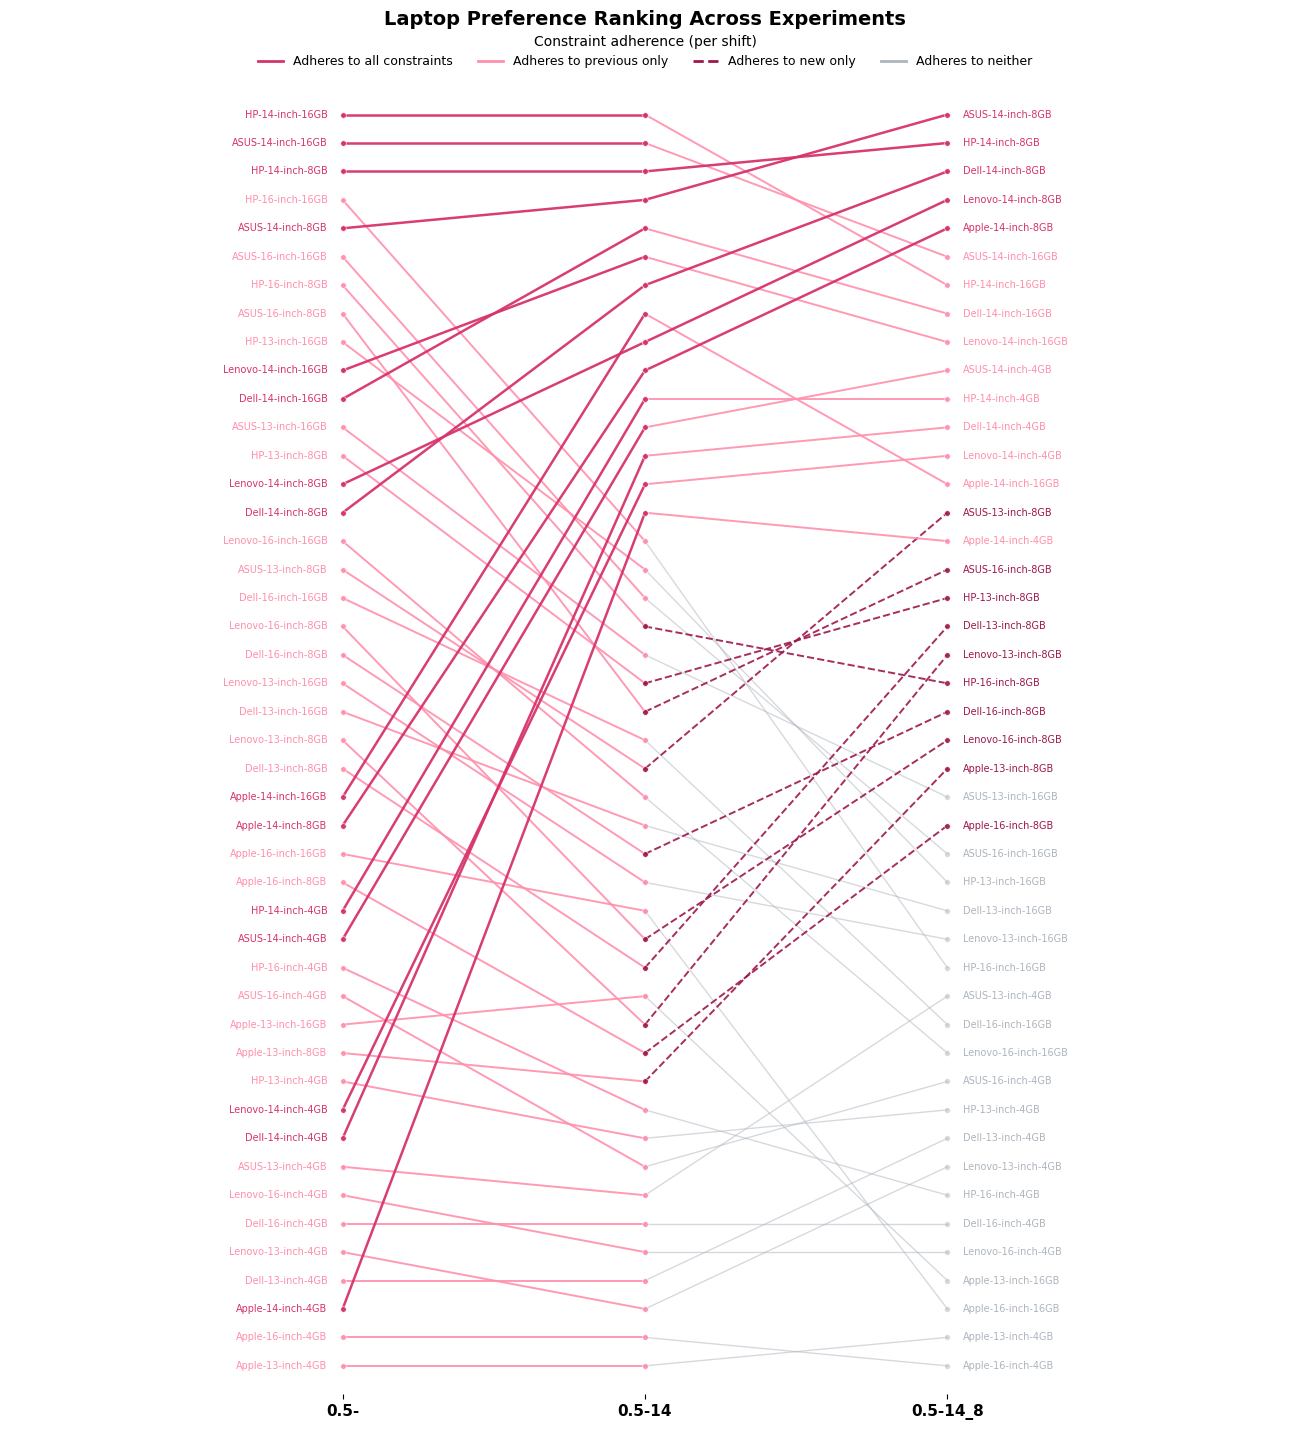

Shift 0.5- -> 0.5-14:
  Adhering  (14-inch, n=15): rho = 0.982
  Violating (not 14-inch, n=30): rho = 0.975
Shift 0.5-14 -> 0.5-14_8:
  Adhering  (14-inch, n=15): rho = 0.664
  Violating (not 14-inch, n=30): rho = 0.614


In [15]:
scores_by_run, run_order, correlation_results = run_laptop_ranking_experiment(
    basedir="data/laptops_robustness",
    filters={"model_size": "0.5"},
    constraint_order=["none", "screen=14-inch", "ram=8GB+screen=14-inch"],
)

Loaded 68339920 -> 72-14
Feature p-values:
  brand_Apple: p-value = 0.0057
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.3710
  brand_Lenovo: p-value = 0.6658
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -10.9136, p-value = 0.0000
Model R-squared: 0.8532, F-statistic p-value: 0.0000
Loaded 68374672 -> 72-14_8
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.9612
  brand_Lenovo: p-value = 0.4434
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -10.4867, p-value = 0.0000
Model R-squared: 0.8800, F-statistic p-value: 0.0000
Note: still missing ['72-'] (job may still be running) - rerun this cell once it lands.


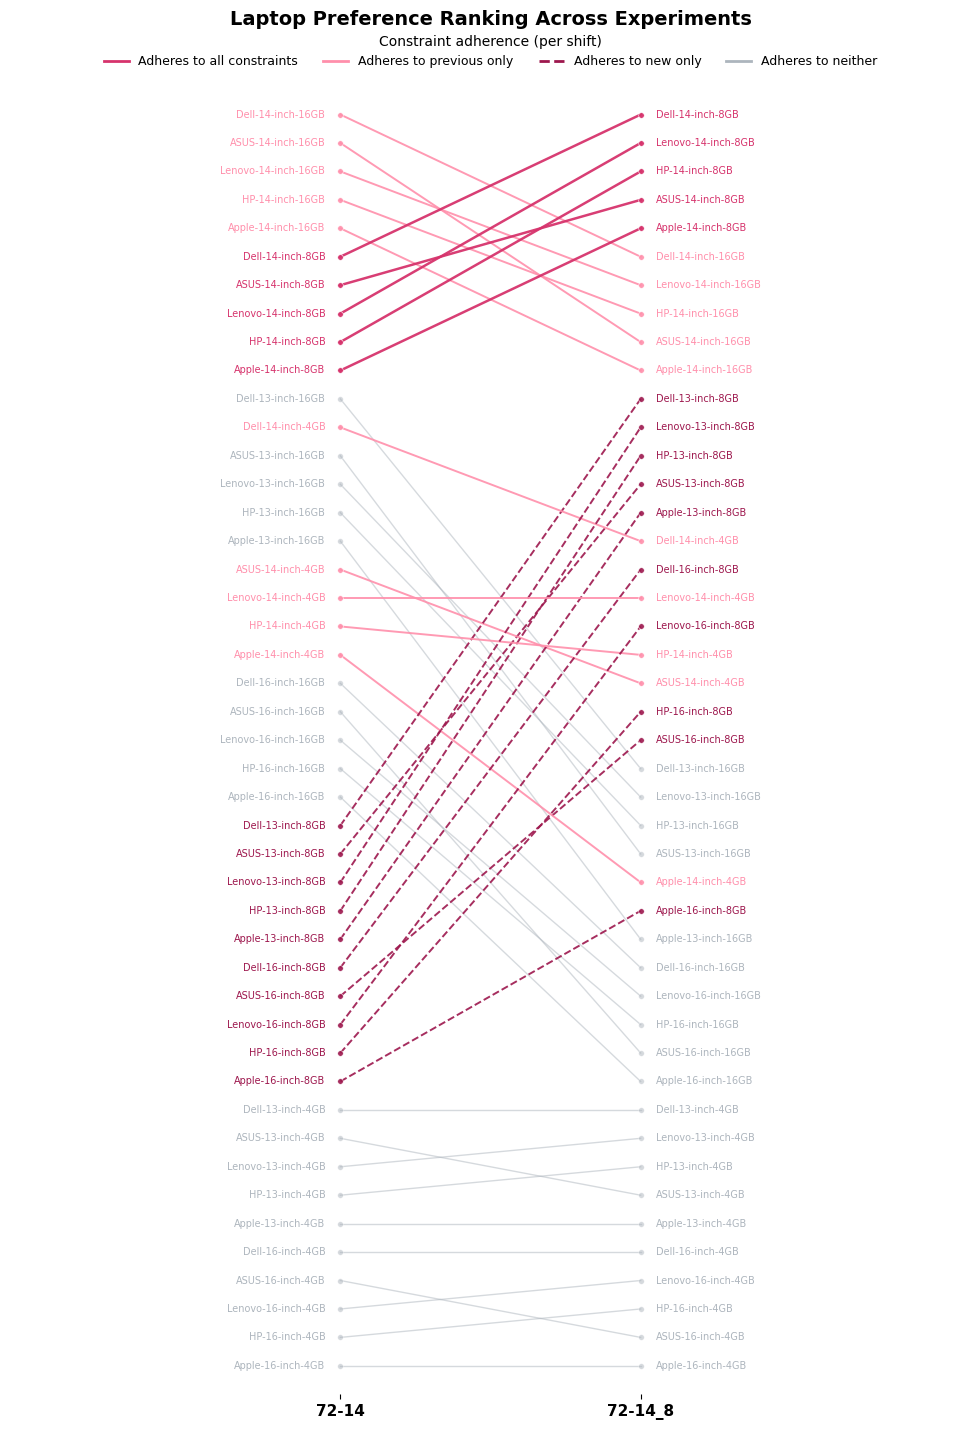

Shift 72-14 -> 72-14_8:
  Adhering  (14-inch, n=15): rho = 0.521
  Violating (not 14-inch, n=30): rho = 0.578


In [28]:
scores_by_run, run_order, correlation_results = run_laptop_ranking_experiment(
    basedir="data/laptops_robustness",
    filters={"model_size": "72"},
    constraint_order=["none", "screen=14-inch", "ram=8GB+screen=14-inch"],
)

## Gemma

Loaded 1271583 -> gemma-1-
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.9571
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -6.9411, p-value = 0.0000
Model R-squared: 0.6539, F-statistic p-value: 0.0000
Loaded 68374673 -> gemma-1-14
Feature p-values:
  brand_Apple: p-value = 0.7844
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.0698
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -5.2509, p-value = 0.0000
Model R-squared: 0.6800, F-statistic p-value: 0.0000
Loaded 68374675 -> gemma-1-14_8
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.0291
  screen_14-inch: p-va

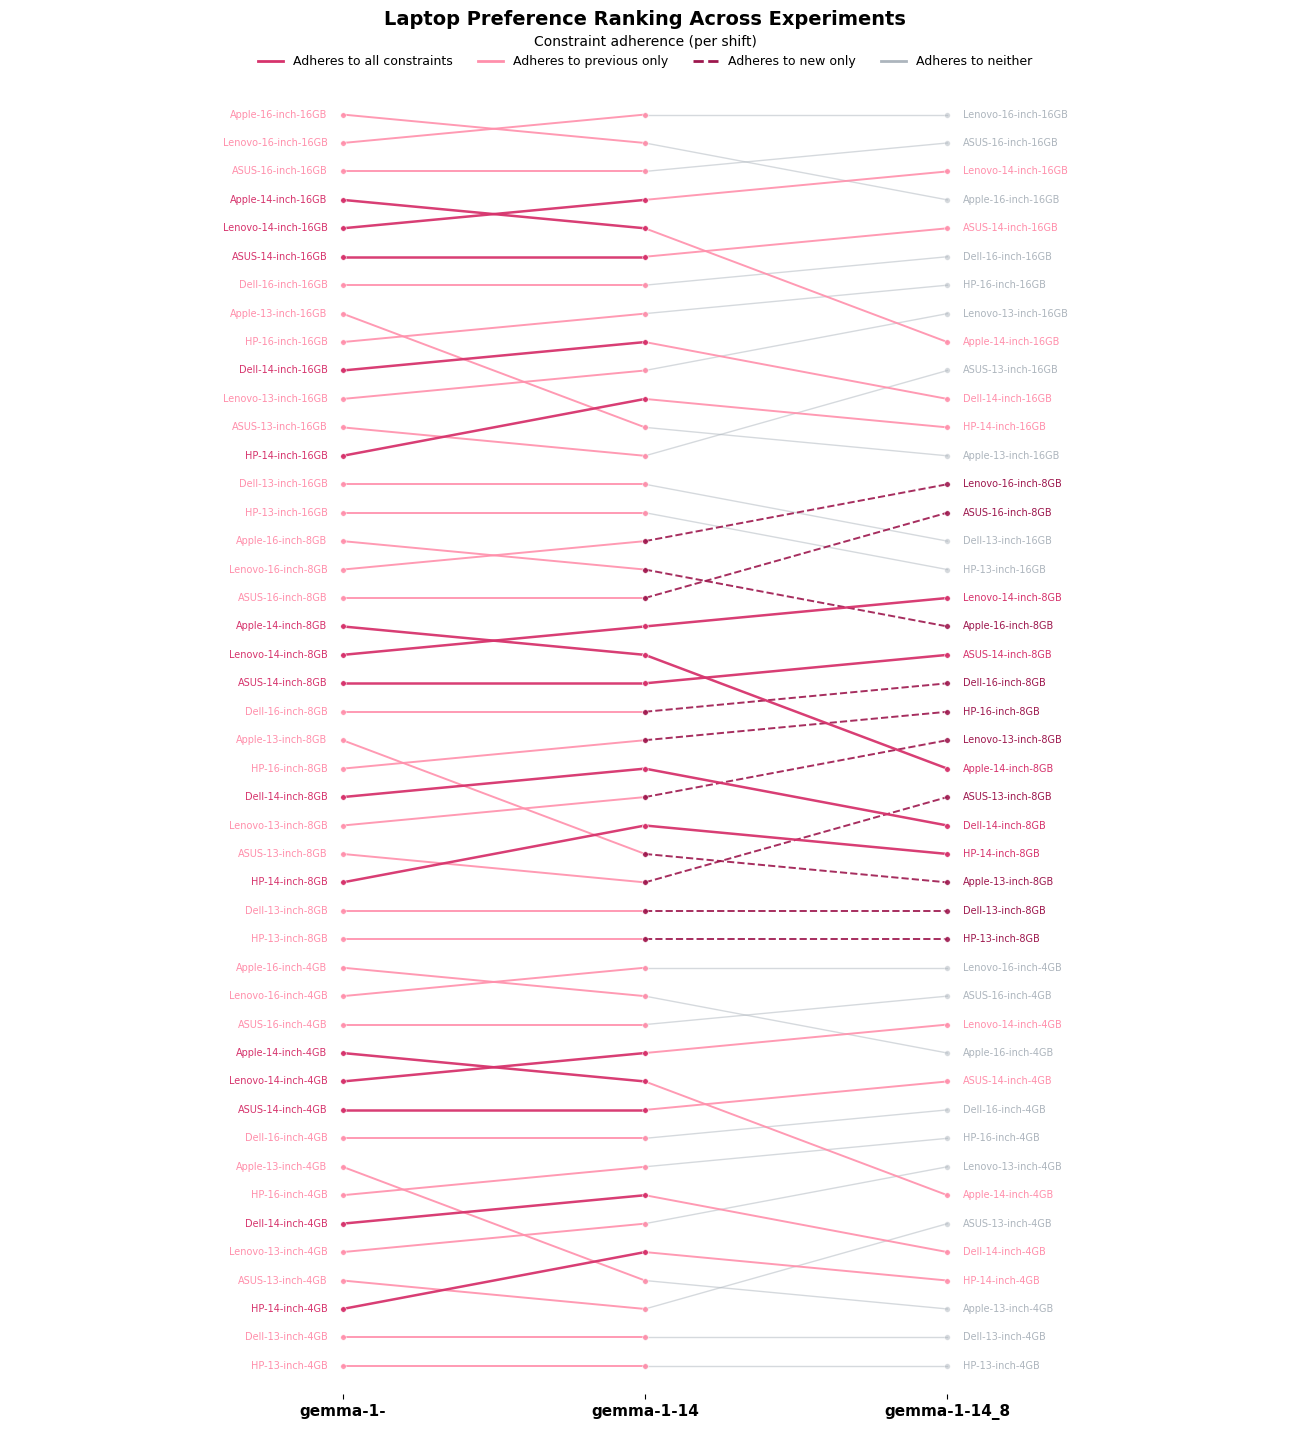

Shift gemma-1- -> gemma-1-14:
  Adhering  (14-inch, n=15): rho = 0.989
  Violating (not 14-inch, n=30): rho = 0.995
Shift gemma-1-14 -> gemma-1-14_8:
  Adhering  (14-inch, n=15): rho = 0.989
  Violating (not 14-inch, n=30): rho = 0.993


In [17]:
scores_by_run, run_order, correlation_results = run_laptop_ranking_experiment(
    basedir="data/laptops_robustness_gemma",
    filters={"model_family": "gemma", "model_size": "1"},
    constraint_order=["none", "screen=14-inch", "ram=8GB+screen=14-inch"],
)

Loaded 68378305 -> gemma-4-14
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.3249
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -9.6798, p-value = 0.0000
Model R-squared: 0.7900, F-statistic p-value: 0.0000
Loaded 68378307 -> gemma-4-14_8
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.1071
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -7.6551, p-value = 0.0000
Model R-squared: 0.7868, F-statistic p-value: 0.0000
Loaded 68378739 -> gemma-4-
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0042
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.0199
  screen_14-inch: p-v

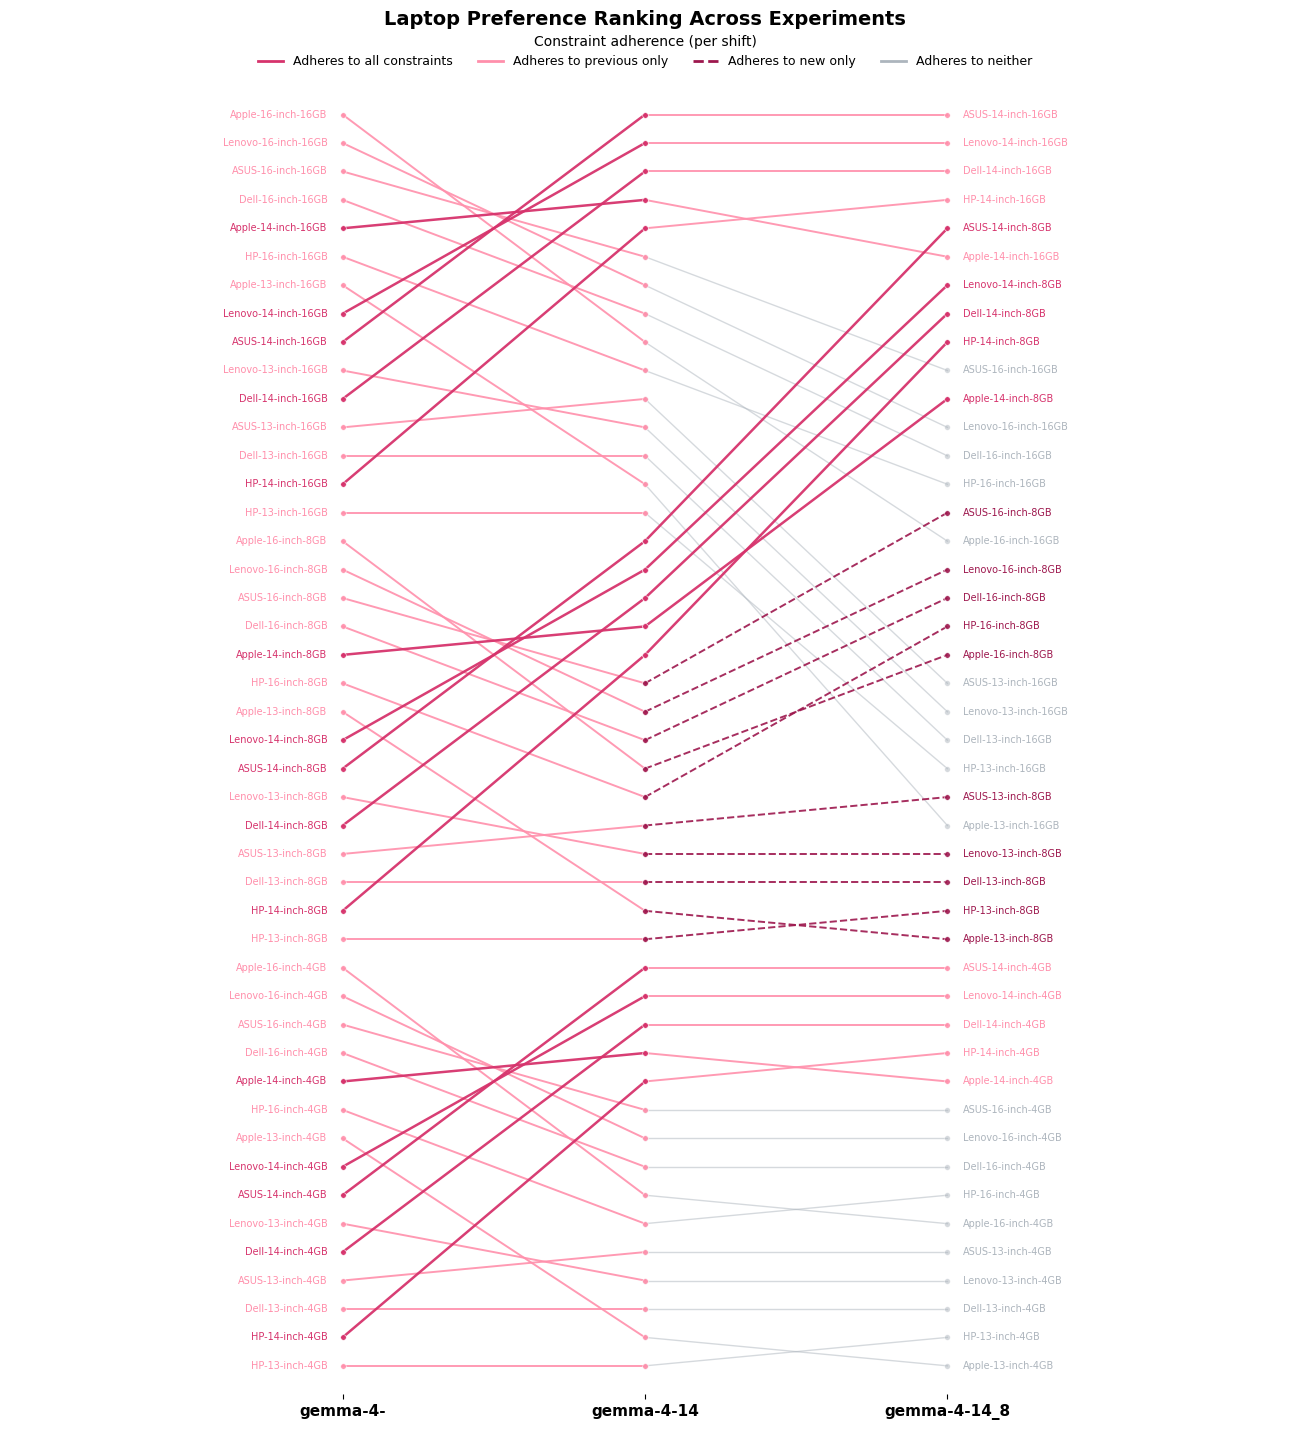

Shift gemma-4- -> gemma-4-14:
  Adhering  (14-inch, n=15): rho = 0.925
  Violating (not 14-inch, n=30): rho = 0.981
Shift gemma-4-14 -> gemma-4-14_8:
  Adhering  (14-inch, n=15): rho = 0.982
  Violating (not 14-inch, n=30): rho = 0.935


In [18]:
scores_by_run, run_order, correlation_results = run_laptop_ranking_experiment(
    basedir="data/laptops_robustness_gemma",
    filters={"model_family": "gemma", "model_size": "4"},
    constraint_order=["none", "screen=14-inch", "ram=8GB+screen=14-inch"],
)

Loaded 68378309 -> gemma-12-14
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.2689
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -9.9669, p-value = 0.0000
Model R-squared: 0.7997, F-statistic p-value: 0.0000
Loaded 68378311 -> gemma-12-14_8
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0009
  brand_Lenovo: p-value = 0.7335
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -9.8551, p-value = 0.0000
Model R-squared: 0.7676, F-statistic p-value: 0.0000
Loaded 68378740 -> gemma-12-
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.4863
  screen_14-inch: 

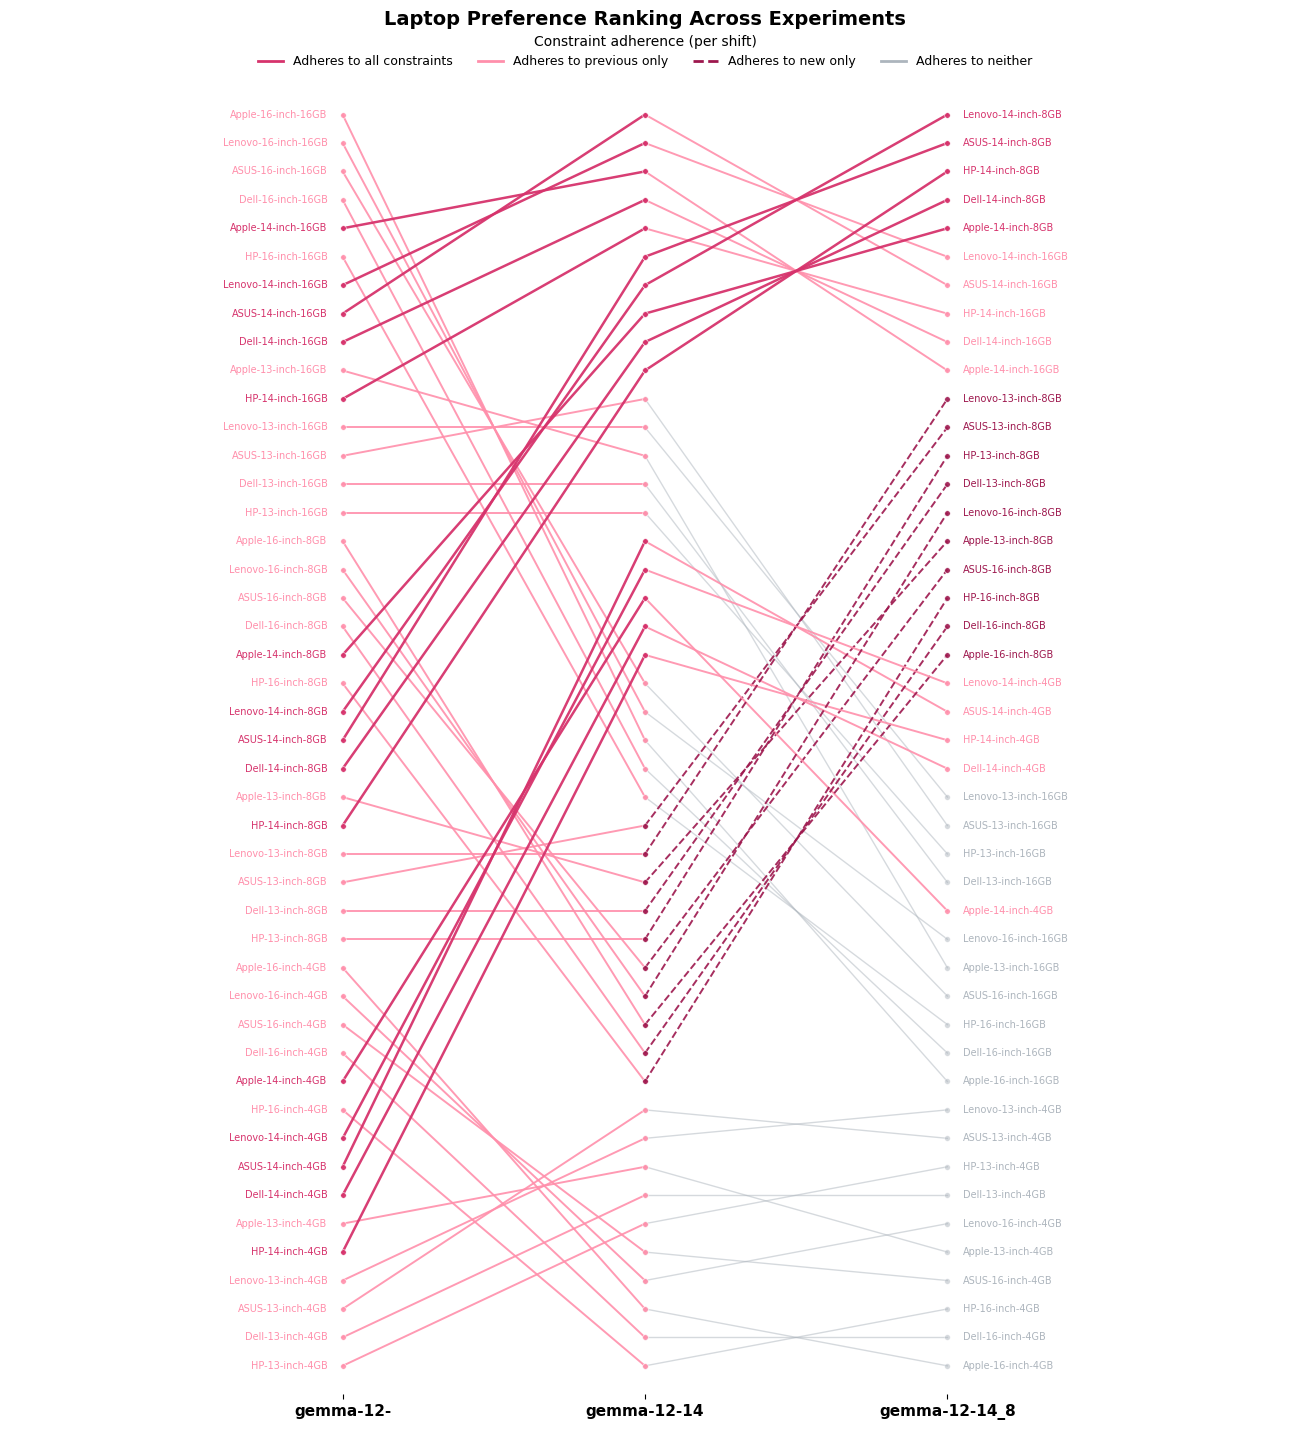

Shift gemma-12- -> gemma-12-14:
  Adhering  (14-inch, n=15): rho = 0.957
  Violating (not 14-inch, n=30): rho = 0.822
Shift gemma-12-14 -> gemma-12-14_8:
  Adhering  (14-inch, n=15): rho = 0.500
  Violating (not 14-inch, n=30): rho = 0.536


In [19]:
scores_by_run, run_order, correlation_results = run_laptop_ranking_experiment(
    basedir="data/laptops_robustness_gemma",
    filters={"model_family": "gemma", "model_size": "12"},
    constraint_order=["none", "screen=14-inch", "ram=8GB+screen=14-inch"],
)

Loaded 68378313 -> gemma-27-14
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.6946
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -7.3577, p-value = 0.0000
Model R-squared: 0.7769, F-statistic p-value: 0.0000
Loaded 68378315 -> gemma-27-14_8
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.2412
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -7.9618, p-value = 0.0000
Model R-squared: 0.7850, F-statistic p-value: 0.0000
Loaded 68378741 -> gemma-27-
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.9535
  screen_14-inch: 

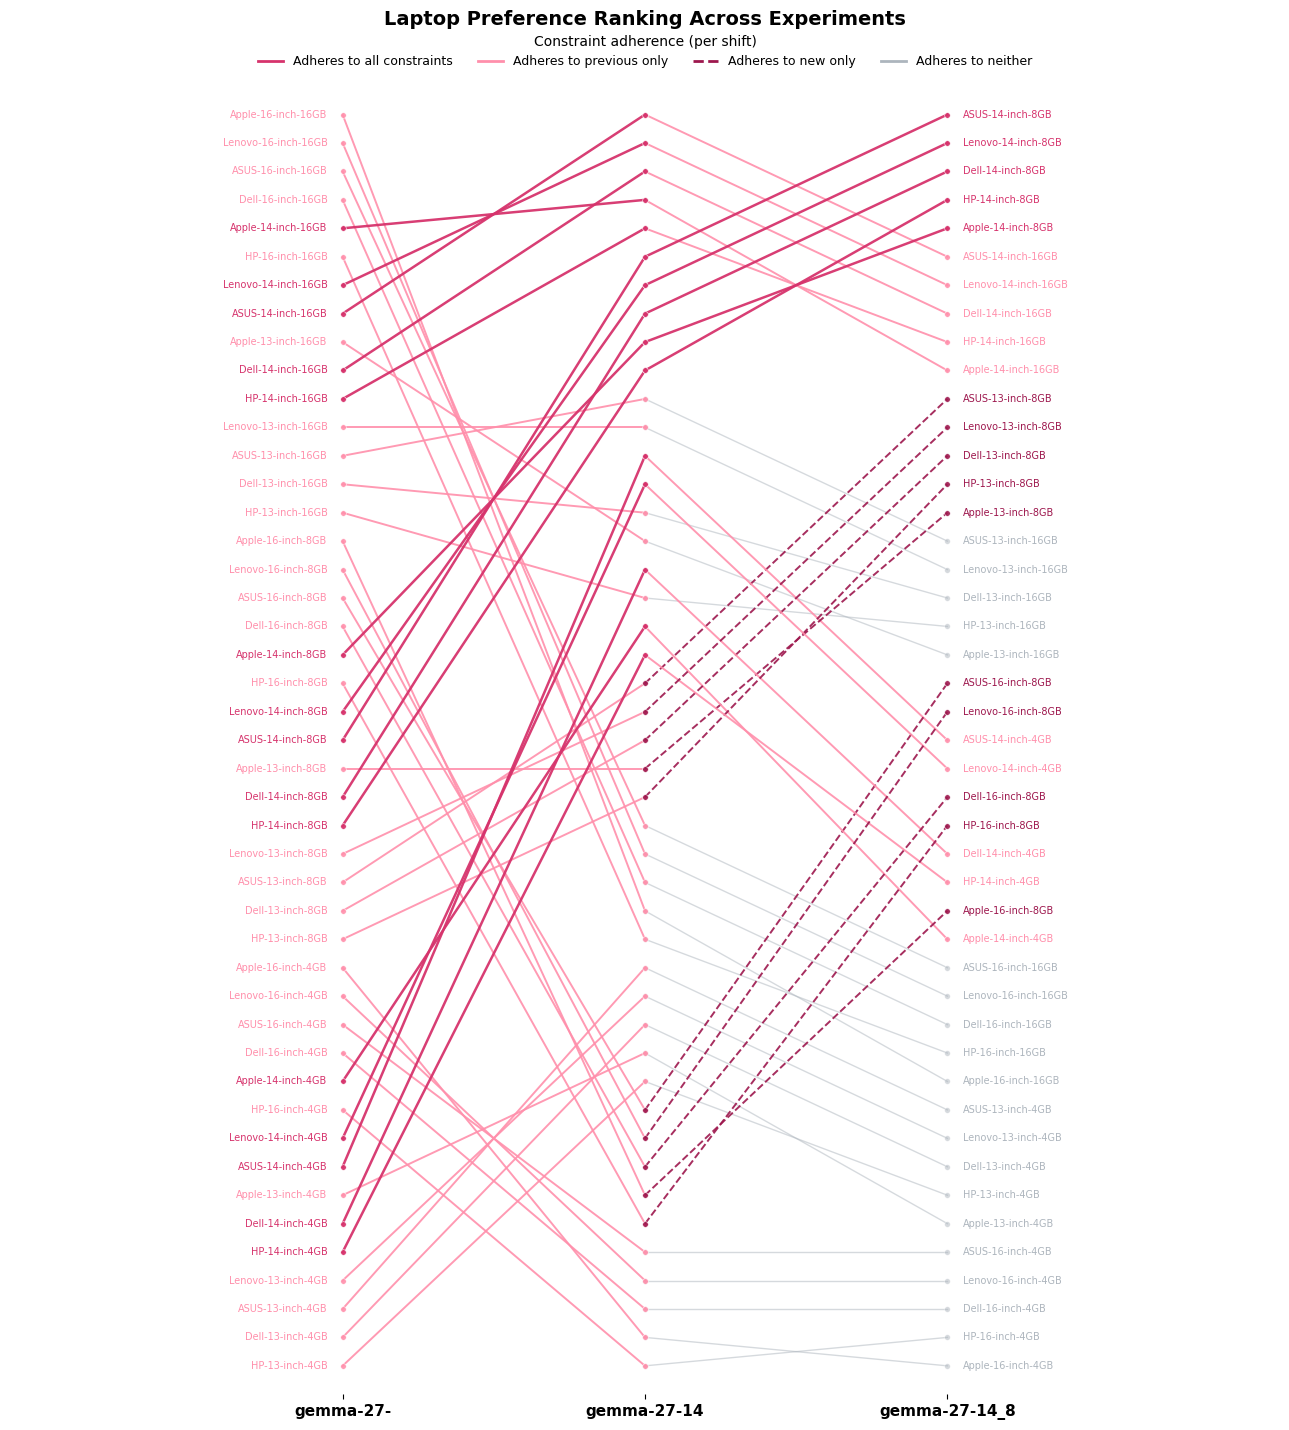

Shift gemma-27- -> gemma-27-14:
  Adhering  (14-inch, n=15): rho = 0.925
  Violating (not 14-inch, n=30): rho = 0.481
Shift gemma-27-14 -> gemma-27-14_8:
  Adhering  (14-inch, n=15): rho = 0.543
  Violating (not 14-inch, n=30): rho = 0.775


In [20]:
scores_by_run, run_order, correlation_results = run_laptop_ranking_experiment(
    basedir="data/laptops_robustness_gemma",
    filters={"model_family": "gemma", "model_size": "27"},
    constraint_order=["none", "screen=14-inch", "ram=8GB+screen=14-inch"],
)

# Misc

In [21]:
records = []
basedir = "data/laptops_robustness"
for filename in os.listdir(basedir):
    config_path = os.path.join(basedir, filename, "config.json")
    scores_path = os.path.join(basedir, filename, "scores.csv")
    if not os.path.isfile(config_path) or not os.path.isfile(scores_path):
        continue
    with open(config_path, "r") as f:
        config = json.load(f)
    records.append({
        'filename': filename,
        'model_family': config.get("model_family", ""),
        'model_size': config.get("model_size", ""), 
        'constraints': config.get("constraints", "") or "",
    })

df = pd.DataFrame(records)
df

,filename,model_family,model_size,constraints
0,68337596,qwen,7,14
1,68339918,qwen,0.5,14
2,68339919,qwen,32,14
3,68339920,qwen,72,14
4,68373840,qwen,7,
5,68373841,qwen,32,
6,68374112,qwen,7,8
7,68374113,qwen,7,14_8
8,68374114,qwen,32,8
9,68374115,qwen,32,14_8


In [22]:
sizes = df['model_size'].unique()
constraints = df['constraints'].unique()
do_we_have = np.zeros((len(sizes), len(constraints)), dtype=int)
for i, size in enumerate(sizes):
    for j, constraint in enumerate(constraints):
        do_we_have[i, j] = ((df['model_size'] == size) & (df['constraints'] == constraint)).sum()
        
do_we_have = pd.DataFrame(do_we_have, index=sizes, columns=constraints)
do_we_have

,14,,8,14_8
7,1,1,1,1
0.5,1,1,1,1
32,1,1,1,1
72,1,0,1,1


In [23]:
records = []
basedir = "data/laptops_robustness_gemma"
for filename in os.listdir(basedir):
    config_path = os.path.join(basedir, filename, "config.json")
    scores_path = os.path.join(basedir, filename, "scores.csv")
    if not os.path.isfile(config_path) or not os.path.isfile(scores_path):
        continue
    with open(config_path, "r") as f:
        config = json.load(f)
    records.append({
        'filename': filename,
        'model_family': config.get("model_family", ""),
        'model_size': config.get("model_size", ""), 
        'constraints': config.get("constraints", "") or "",
    })

df = pd.DataFrame(records)
df

,filename,model_family,model_size,constraints
0,1271583,gemma,1,
1,68374673,gemma,1,14
2,68374674,gemma,1,8
3,68374675,gemma,1,14_8
4,68378305,gemma,4,14
5,68378306,gemma,4,8
6,68378307,gemma,4,14_8
7,68378309,gemma,12,14
8,68378310,gemma,12,8
9,68378311,gemma,12,14_8


# Interpreting Shifts via Feature Weights

The bump chart above only shows each laptop's *rank*, aggregated across all its features. That's good for spotting *that* something shifted, but not *why*. Since `fit_item_bradley_terry` computes each laptop's utility as a **sum of independent per-feature weights** (`brand_X + screen_Y + ram_Z`), we have a much richer signal sitting right there in `fit_feature_based_bradley_terry`'s `feature_scores` - one coefficient per feature *level*, per run. Plan for using it:

1. **Feature-weight trajectories.** Track each individual feature level's own coefficient (`brand_Apple`, `screen_14-inch`, `ram_8GB`, ...) across the constraint sequence, instead of only the aggregated per-laptop rank. This separates the constraint's intended main effect (screen/ram weights swinging as expected) from *collateral drift* in unrelated dimensions - e.g. does brand bias actually flatten when we add a screen constraint, or does it just get diluted in the rank chart because screen now dominates the sum?
2. **Shift decomposition / attribution.** Because item utility is additive, the per-item utility delta between two runs decomposes *exactly* into per-feature-dimension contributions: `Δutility = Δbrand + Δscreen + Δram`. For any laptop whose rank jumped a lot in the bump chart, this tells us *which* dimension actually drove the move, rather than just that it moved.
3. **(Not implemented here, natural next step)** Use the existing per-feature p-values to flag which specific level-level deltas are statistically real vs. noise, the same way `plot_preference_shift` already fades insignificant bars - extended across all N runs instead of just two.

Implemented below for `qwen-32` as a first pass.

Loaded 68339919 -> 32-14
Feature p-values:
  brand_Apple: p-value = 0.0567
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.0147
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -6.9349, p-value = 0.0000
Model R-squared: 0.8050, F-statistic p-value: 0.0000
Loaded 68373841 -> 32-
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.0000
  screen_14-inch: p-value = 0.0000
  screen_16-inch: p-value = 0.0000
  ram_4GB: p-value = 0.0000
  ram_8GB: p-value = 0.0000
Positional bias (gamma): -6.9840, p-value = 0.0000
Model R-squared: 0.8533, F-statistic p-value: 0.0000
Loaded 68374115 -> 32-14_8
Feature p-values:
  brand_Apple: p-value = 0.0000
  brand_Dell: p-value = 0.0000
  brand_HP: p-value = 0.0000
  brand_Lenovo: p-value = 0.0006
  screen_14-inch: p-value = 0.0000
 

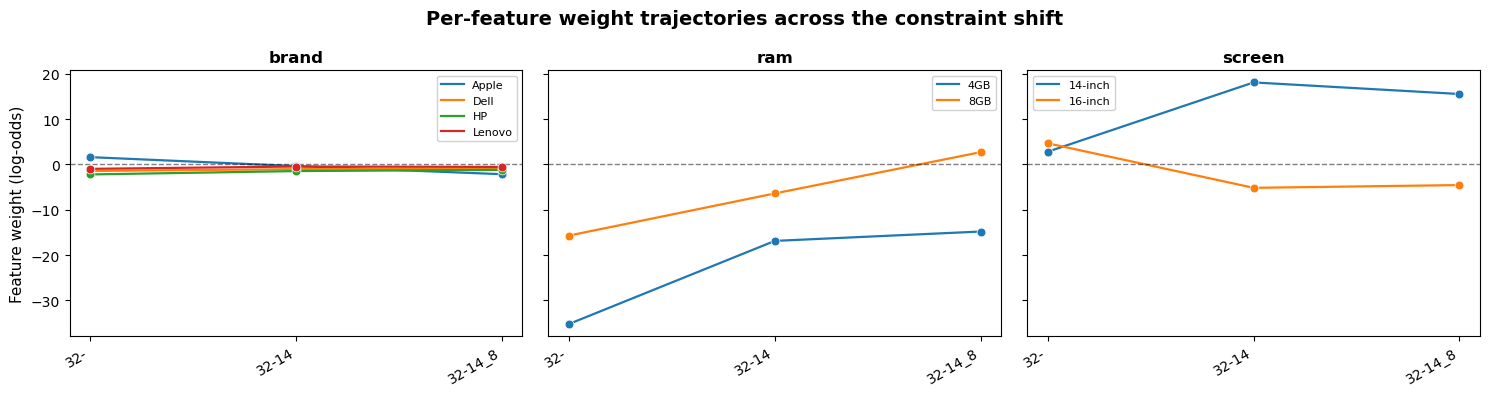

(<Figure size 1500x400 with 3 Axes>,
 array([<Axes: title={'center': 'brand'}, ylabel='Feature weight (log-odds)'>,
        <Axes: title={'center': 'ram'}>,
        <Axes: title={'center': 'screen'}>], dtype=object))

In [25]:
## Applied to qwen-32

# 1. Feature-weight trajectories: reuse load_scores_by_run, just swap in the
# feature-level fit function instead of the item-level one.
feature_results_by_run, run_order, constraints_by_run = load_scores_by_run(
    basedir="data/laptops_robustness",
    filters={"model_size": "32"},
    constraint_order=["none", "screen=14-inch", "ram=8GB+screen=14-inch"],
    fit_fn=fit_feature_based_bradley_terry,
)
plot_feature_weight_trajectories(feature_results_by_run, run_order)


=== Shift 32- -> 32-14: top movers, decomposed by feature ===


,item,delta_brand,delta_screen,delta_ram,delta_total
0,HP-14-inch-4GB,0.743430,15.287457,18.322207,34.353094
1,Lenovo-14-inch-4GB,0.510728,15.287457,18.322207,34.120392
2,Dell-14-inch-4GB,0.406422,15.287457,18.322207,34.016086
3,ASUS-14-inch-4GB,0.000000,15.287457,18.322207,33.609664
4,Apple-14-inch-4GB,-1.966725,15.287457,18.322207,31.642940
5,HP-14-inch-8GB,0.743430,15.287457,9.294533,25.325420
6,Lenovo-14-inch-8GB,0.510728,15.287457,9.294533,25.092718
7,Dell-14-inch-8GB,0.406422,15.287457,9.294533,24.988412
8,ASUS-14-inch-8GB,0.000000,15.287457,9.294533,24.581990
9,Apple-14-inch-8GB,-1.966725,15.287457,9.294533,22.615266


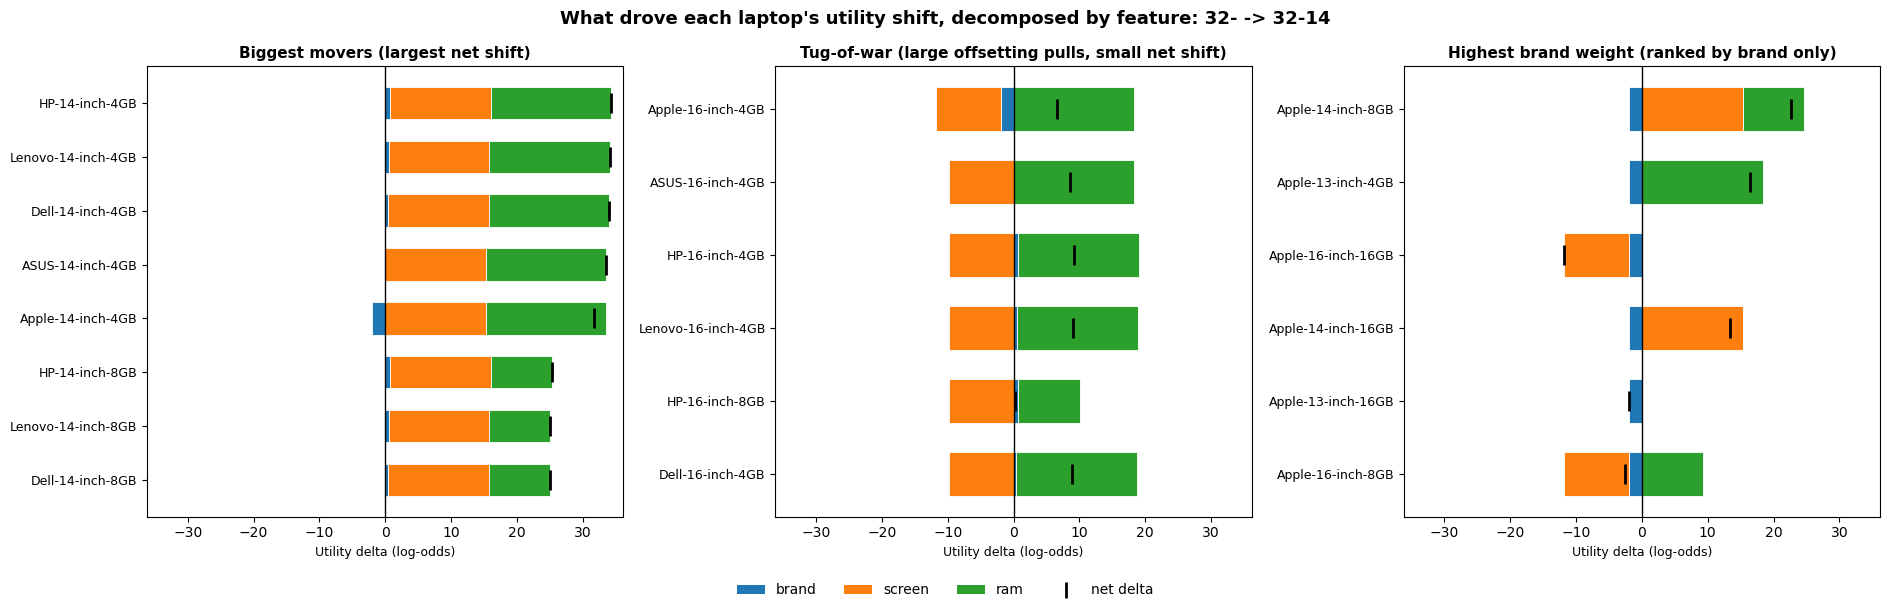


=== Shift 32-14 -> 32-14_8: top movers, decomposed by feature ===


,item,delta_brand,delta_screen,delta_ram,delta_total
0,HP-16-inch-8GB,0.269934,0.60659,9.103489,9.980013
1,Dell-16-inch-8GB,0.012940,0.60659,9.103489,9.723020
2,ASUS-16-inch-8GB,0.000000,0.60659,9.103489,9.710079
3,Lenovo-16-inch-8GB,-0.086946,0.60659,9.103489,9.623133
4,HP-13-inch-8GB,0.269934,0.00000,9.103489,9.373423
5,Dell-13-inch-8GB,0.012940,0.00000,9.103489,9.116430
6,ASUS-13-inch-8GB,0.000000,0.00000,9.103489,9.103489
7,Lenovo-13-inch-8GB,-0.086946,0.00000,9.103489,9.016543
8,Apple-16-inch-8GB,-1.794386,0.60659,9.103489,7.915694
9,Apple-13-inch-8GB,-1.794386,0.00000,9.103489,7.309104


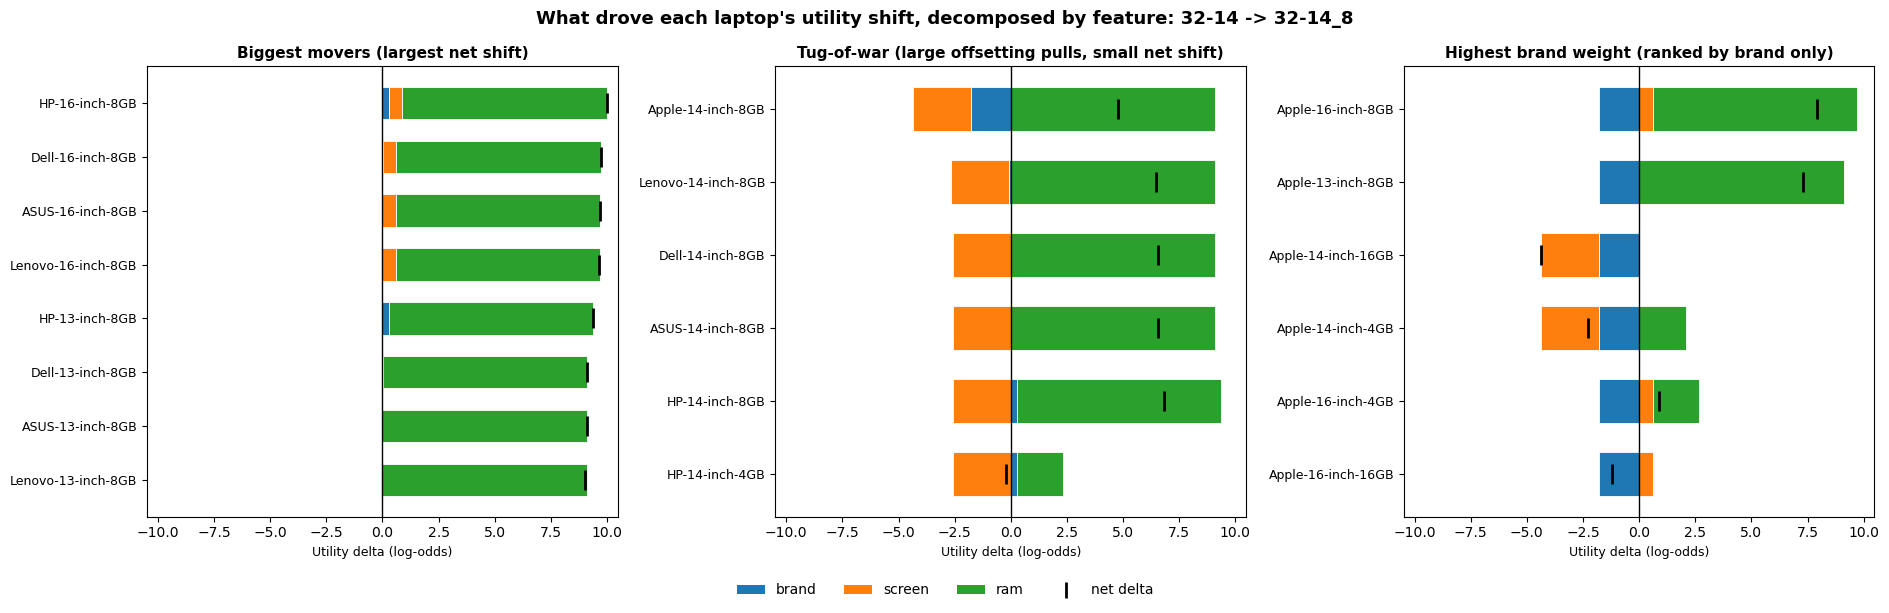

In [26]:
# 2. Shift decomposition: for each consecutive shift, attribute every
# laptop's utility delta to brand vs screen vs ram, then visualize a curated
# set of the most interesting laptops (biggest movers + biggest internal
# tug-of-war) rather than the full 45-laptop set, which is unreadable as a
# chart and mostly just laptops passively following the constraint's effect.
item_feature_map, base_features = get_item_feature_map(
    find_any_scores_csv("data/laptops_robustness", {"model_size": "32"})
)

for run_a, run_b in zip(run_order, run_order[1:]):
    print(f"\n=== Shift {run_a} -> {run_b}: top movers, decomposed by feature ===")
    decomposition = decompose_item_shift(feature_results_by_run, run_a, run_b, item_feature_map, base_features)
    display(decomposition.head(10))
    plot_shift_attribution(decomposition, base_features, run_a, run_b)

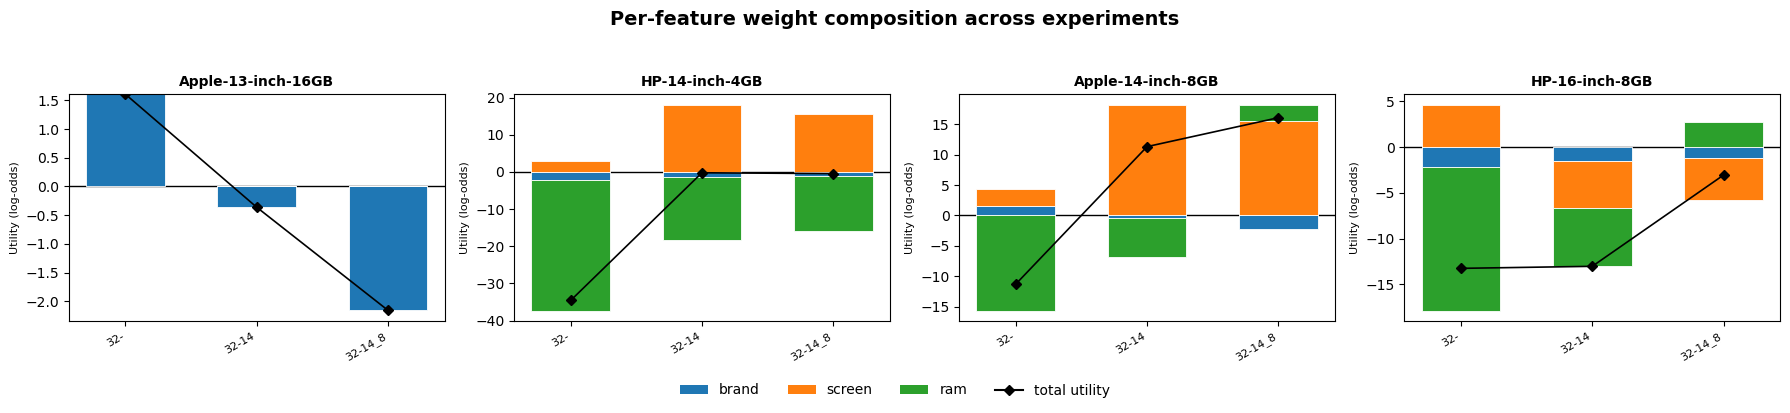

(<Figure size 1800x400 with 4 Axes>,
 array([[<Axes: title={'center': 'Apple-13-inch-16GB'}, ylabel='Utility (log-odds)'>,
         <Axes: title={'center': 'HP-14-inch-4GB'}, ylabel='Utility (log-odds)'>,
         <Axes: title={'center': 'Apple-14-inch-8GB'}, ylabel='Utility (log-odds)'>,
         <Axes: title={'center': 'HP-16-inch-8GB'}, ylabel='Utility (log-odds)'>]],
       dtype=object))

In [27]:
# 3. Per-laptop weight composition across every experiment, for a hand-picked
# set of laptops (reusing the ones the two shifts above already flagged as
# interesting: the cleanest brand-only signal, and the biggest movers from
# each shift) - stacked bars of actual feature WEIGHT per run, not deltas.
chosen_items = ["Apple-13-inch-16GB", "HP-14-inch-4GB", "Apple-14-inch-8GB", "HP-16-inch-8GB"]
plot_laptop_feature_weights(feature_results_by_run, run_order, item_feature_map, base_features, chosen_items)